In [10]:
from __future__ import print_function
import pylab as pl
import numpy as np
import pandas as pd
import json



%pylab inline
kelly_colors_hex = [
    '#FFB300', # Vivid Yellow
    '#803E75', # Strong Purple
    '#FF6800', # Vivid Orange
    '#A6BDD7', # Very Light Blue
    '#C10020', # Vivid Red
    '#CEA262', # Grayish Yellow
    '#817066', # Medium Gray
    '#007D34', # Vivid Green
    '#F6768E', # Strong Purplish Pink
    '#00538A', # Strong Blue
    '#FF7A5C', # Strong Yellowish Pink
    '#53377A', # Strong Violet
    '#FF8E00', # Vivid Orange Yellow
    '#B32851', # Strong Purplish Red
    '#F4C800', # Vivid Greenish Yellow
    '#7F180D', # Strong Reddish Brown
    '#93AA00', # Vivid Yellowish Green
    '#593315', # Deep Yellowish Brown
    '#F13A13', # Vivid Reddish Orange
    '#232C16', # Dark Olive Green
    ]

newparams = {
  "lines.linewidth": 2.0,
  "axes.edgecolor": "#aaaaaa",
  "patch.linewidth": 1.0,
  "legend.fancybox": 'false',
  "axes.color_cycle": kelly_colors_hex,
  "axes.facecolor": "#ffffff",
  "axes.labelsize": "large",
  "axes.grid": 'true',
  "patch.edgecolor": "#555555",
  "axes.titlesize": "x-large",
  "svg.embed_char_paths": "path",
}
pl.rcParams.update(newparams)
font = {'family' : 'normal',
        'weight' : 'normal',
        'size'   : 22}

pl.rc('font', **font)

Populating the interactive namespace from numpy and matplotlib


#TIME SERIES ANALYSIS

#Goal: Find outliers, trends and periodicity in the MTA turnstyle data
    

##DATA:
MTA subway fares. It is a complete dataset of
rides logged by card swipes for 600 Manhattan stations.

The data was organized  by Sina Kashuk at CUSP.

It contains 23 different subway card types 
(e.g. monthly pass, daily pass, Act for Disability pass…) as follows:


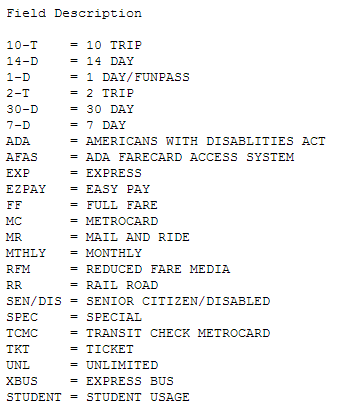

In [11]:
from IPython.display import Image
Image(filename = "Ridetypes.png")

Each time series (per station, per ticket type) contains
the number of swipes per week for 194 weeks 
from 05/21/2010 to 02/21/2014. 

it is given to you as a python data cube.  
you can load it as np.load(“MTA_Fare.npy") and 
you will end up with a python numpy array of 
shape (600,23,194)

###reading in data

In [12]:
mta = np.load("MTA_Fare.npy")
#the shape of the data cube
mta.shape


(600, 23, 194)

In [13]:
#the length of each time series:
N = mta.shape[2]

creating a human readable ordered ride-type list

In [14]:
ridetype = np.array(['10t', '14d', '1d', '2t', '30d', '7d', 'ada', 'afas', 'exp','ez',
            'ff','mc','mr','month','rfm','rr','sen','spec','tcmc','t',
            'umlim','xbus','stud'])

###i am gonna begin by plotting the data in various ways just to see what i am dealing with

min -1.000000, max 337247.000000, mean 2157.826203, std 10143.679568


/Users/fbianco/Library/Enthought/Canopy_64bit/User/lib/python2.7/site-packages/matplotlib/font_manager.py:1282: UserWarning: findfont: Font family [u'normal'] not found. Falling back to Bitstream Vera Sans
  (prop.get_family(), self.defaultFamily[fontext]))


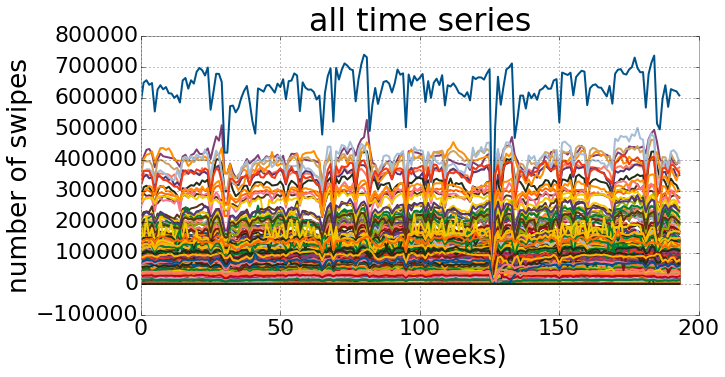

In [15]:
pl.figure(figsize = (10,5))
for i in range(mta.shape[0]):
    allrides = [sum(mta[i,:,j]) for j in range(mta.shape[2])]
    pl.plot(allrides)
    pl.xlabel("time (weeks)")
    pl.ylabel("number of swipes")
print ("min {0:f}, max {1:f}, mean {2:f}, std {3:f}".format(mta.flatten().min(), 
                                                            mta.flatten().max(), 
                                                            mta.flatten().mean(), 
                                                            mta.flatten().std()))
pl.title("all time series")

In [16]:
#remove missing values that are set to -1

            
            
mta = mta.astype(float)
mta[mta == -1] = float('NaN')


##i want to explore the data by ride type a bit:
##i am selecting only types of cards that i am familiar with, and summing over each station for each one of them
##also I am  plotting the y axis in log space to better see features that may be hidden in the bottom part of the y axis, where most of the time series fell in the plot above


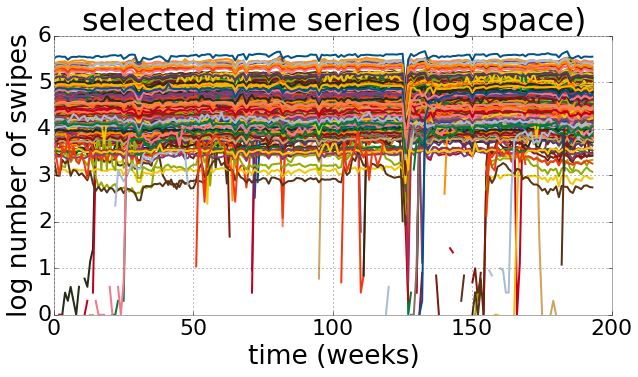

In [17]:
rideindx = [np.where(ridetype == tp)[0][0] for tp in ['10t', '14d', '1d', '2t', '30d', '7d', 'ez','t']]
pl.figure(figsize = (10,5))
for i in range(mta.shape[0]):
    allrides = [sum(mta[i,rideindx,j]) for j in range(mta.shape[2])]
    pl.plot(np.log10(allrides))
    pl.xlabel("time (weeks)")
    pl.ylabel("log number of swipes")
pl.title("selected time series (log space)")

###This is not much more insightful than the previous plot. what if i normalize each time series by deviding it by its mean?


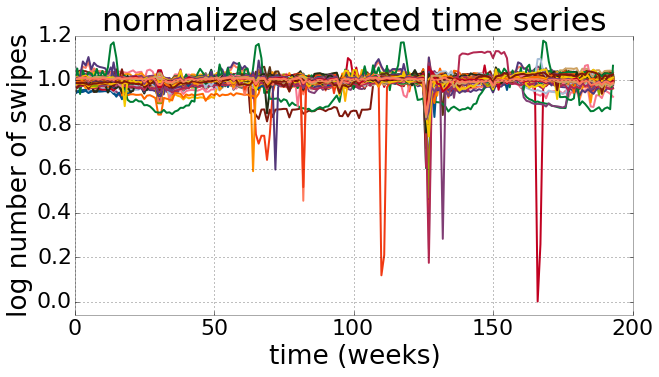

In [18]:
pl.figure(figsize = (10,5))
for i in range(mta.shape[0]):
    allrides = np.array([sum(mta[i,rideindx,j]) for j in range(mta.shape[2])])
    pl.plot(np.log10(allrides)/np.log10(allrides.mean()))
    pl.xlabel("time (weeks)")
    pl.ylabel("log number of swipes")
    pl.ylim(pl.ylim()[0], 1.2)
pl.title("normalized selected time series")

#making an array of datetimes (the x axis of my plots)

In [19]:
#the dates are supposed to be from 5/21/2010 to 02/21/2014. 
#i do not know if the range is inclusive: is 02/21 the last day? 
#or the beginning of the last week? 
#I have 194 datapoints in each ts (timeseries for short)
#but there are 196 weeks b/w 05/21/2010 & 02/21/2014
rng = pd.date_range('05/21/2010', '02/21/2014', freq='W')
print (len(rng))
rng = pd.date_range('05/21/2010', '02/15/2014', freq='W')
print (len(rng))

196
195


In [20]:
#still not right: i am going to leave the initial date 
#and make a 194 weeks array (I know 194 is the right length, since its the length of the ts!)
#then perhaps i can verify if i have the right date when i look for events
rng = pd.date_range('05/21/2010', periods=N, freq='W')


In [21]:
#How does the total sum of all time series look?

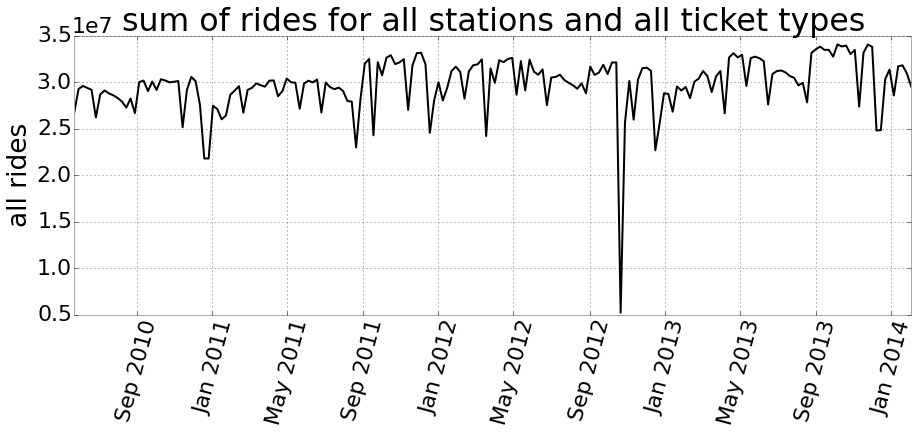

In [22]:
allrides = np.nansum(np.nansum(mta,axis=0), axis=0)
pl.figure(figsize=(15,5))
pl.plot(rng, allrides, 'k-')
pl.title("sum of rides for all stations and all ticket types")
pl.xticks(rotation = 75)
pl.ylabel("all rides")


#TASK 1: looking for the most significant event
##there is an obviously significant event that affects the total sum of all rides. 
i am going to look for it by setting a 3-sigma threshold, and look at events that cross it: events that are above or below the mean +/- 3 standard deviations

In [23]:

#this function calculates the N-sigma level over a rolling window given a window size 
#(with default sigma and window 3 and 10 respectively if nothing is specified)
def threesigma(y, window=10, sigmas=3):
    #note that I am padding the output array with NaN where I am closer than 1/2 of window size
    #to either end of the array 
    return sigmas*np.concatenate([np.zeros(window/2)+float(NaN),
                      [np.nanstd(y[i - window/2 : i + window/2 + 1]) for i in range(
                    window/2, len(y)-window/2)] , np.zeros(window/2)+float(NaN)])


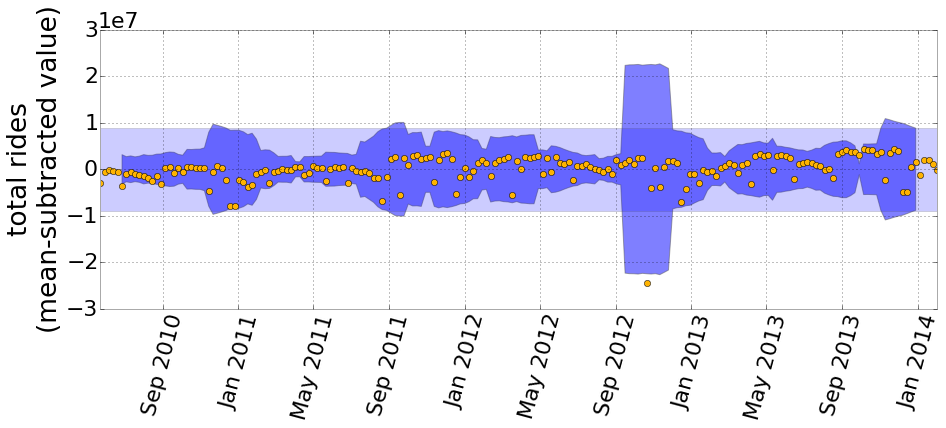

In [24]:
#window: 10 points
w = 10

pl.figure(figsize = (15,5))
pl.plot(rng, allrides - np.nanmean(allrides), 'o')
global_std =  np.nanstd(allrides - np.nanmean(allrides))
pl.fill_between(rng, 
                threesigma(allrides , w), 
                -threesigma(allrides , w), alpha=0.5, label=r"local $3-\sigma$")
pl.fill_between(rng, 
                global_std*3, 
                -global_std*3, alpha = 0.2, label=r"global $3-\sigma$")
pl.xticks(rotation = 75)
pl.ylabel("total rides \n(mean-subtracted value)")

#Caption: 
##the time series resulting from summing over all stations and all ride types, mean subtracted to center it on 0, and its global (light blue)  and local (dark blue) 3-sigma thresholds.
##notice that the most significant event is the only event that is 3-sigma significant in the time seris considering a threshold based on the global variation of the time series
##and it is also one of only 2 only significant events considering a local 3-sigma threshold calculated over a 10 week rolling window. The other event is at the beginning of my rolling window: it is an artifact of the way the window is calculatedand it is (just above the 3-sigma level)

In [25]:
print ("main event:", rng[allrides-mean(allrides) < -global_std*3])
print ("main event:", rng[allrides-mean(allrides) < -threesigma(allrides , w)])


main event: DatetimeIndex(['2012-10-21'], dtype='datetime64[ns]', freq='W-SUN', tz=None)
main event: DatetimeIndex(['2010-06-27', '2012-10-21'], dtype='datetime64[ns]', freq=None, tz=None)


###The main event is in mid-October 2012. I believe that it is Hurricane Sandy. However Hurricane Sandy hit NYC on 10/29
###so it looks line my guess of how to set the dates given the 2 weeks inconsistency was not correct:
###I will recreate the date range starting 1 week later the supposed stard date

In [26]:
rng = pd.date_range('05/28/2010', periods=194, freq='W')
print ("main event:", rng[allrides-mean(allrides)<-threesigma(allrides , w)])


main event: DatetimeIndex(['2010-07-04', '2012-10-28'], dtype='datetime64[ns]', freq=None, tz=None)


##to be sure I got the dates right I can look at the next most significant event by removing the Sandy event and looking at the global 3-sigma threshold again

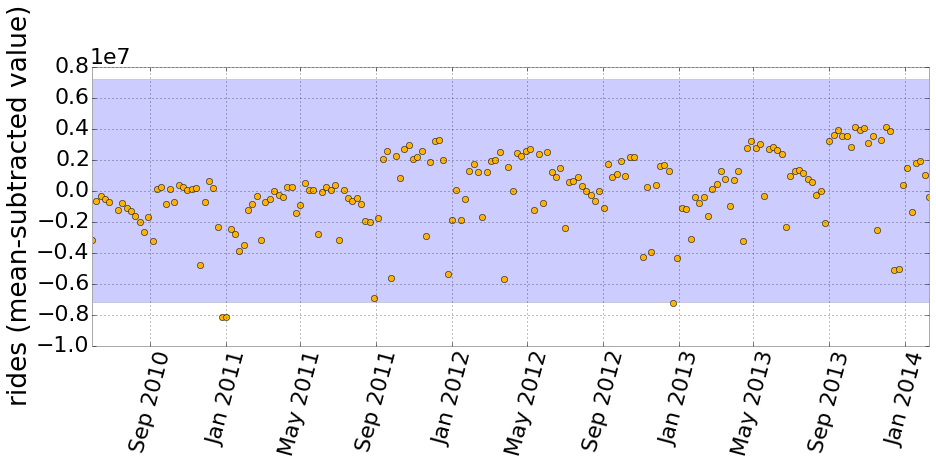

In [27]:

pl.figure(figsize = (15,5))
allrides[allrides-mean(allrides)<-threesigma(allrides , w)]=float(NaN)
pl.plot(rng, allrides - np.nanmean(allrides), 'o')
global_std =  np.nanstd(allrides - np.nanmean(allrides))
pl.fill_between(rng, 
                global_std*3, 
                -global_std*3, alpha = 0.2, label=r"global $3-\sigma$")
pl.xticks(rotation = 75)
pl.ylabel("rides (mean-subtracted value)")


In [28]:
print ("other big events:",  rng[allrides-np.nanmean(allrides)<-global_std*3])

other big events: DatetimeIndex(['2010-12-26', '2011-01-02', '2012-12-23'], dtype='datetime64[ns]', freq=None, tz=None)


#the blizzard of Dec 26 2010 is also recovered in the data giving me confidence that we recovered the right date range
(athough I do not know if the date corresponds to the beginning or the end of the week period so some ambiguity remains

#TASK 2: looking for trends

##to look for trends on a ridership type basis I will work with smooth time series, summing over all stations and smoothing with a rolling mean filter with a windoe of 10 weeks

In [29]:
smoothrides = np.empty_like(mta[0])
countratio = np.zeros(len(mta[0]), float)
for i in range(mta.shape[1]):
    mta_allsum = mta[:,i,:]
    
    #rolling mean to smooth structure on short time scales and summing over all stations
    smoothrides[i] = pd.rolling_mean(np.nansum(mta_allsum, axis=0), 10)
    countratio[i] = np.nanmean(smoothrides[i][:10])/np.nanmean(smoothrides[i][-10:])
    print ("index {0:02d}\t ratio of beginning to end {1:.2f}\t \
    standard deviation {2:.2f})".format(
            i, countratio[i], 
            np.nanstd(smoothrides[i])))
   

index 00	 ratio of beginning to end 0.95	     standard deviation 546777.62)
index 01	 ratio of beginning to end 0.75	     standard deviation 64593.90)
index 02	 ratio of beginning to end 0.85	     standard deviation 5767.41)
index 03	 ratio of beginning to end 1.03	     standard deviation 8828.00)
index 04	 ratio of beginning to end 0.93	     standard deviation 3624.09)
index 05	 ratio of beginning to end 0.69	     standard deviation 631955.02)
index 06	 ratio of beginning to end 1.09	     standard deviation 473487.37)
index 07	 ratio of beginning to end 4924.35	     standard deviation 3794.93)
index 08	 ratio of beginning to end 94109.11	     standard deviation 101444.89)
index 09	 ratio of beginning to end 503545.13	     standard deviation 206370.78)
index 10	 ratio of beginning to end 1.15	     standard deviation 18800.95)
index 11	 ratio of beginning to end 0.81	     standard deviation 25371.32)
index 12	 ratio of beginning to end 0.00	     standard deviation 61154.07)
index 13	 ra

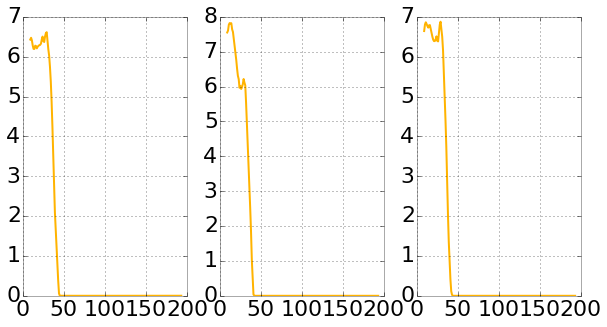

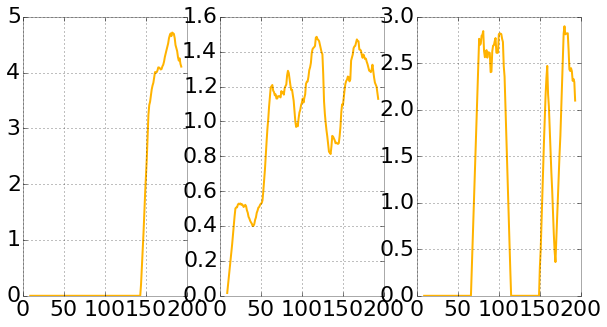

In [30]:
#the rides with crazy high or really low ratios are probably not what i am looking for, 
#but rather discontinued cards etc, card types started at some point in my range...:
fig = pl.figure(figsize=(10,5))
ax = fig.add_subplot(131)
pl.plot(smoothrides[7]/np.nanmean(smoothrides[7]))
ax = fig.add_subplot(132)
pl.plot(smoothrides[8]/np.nanmean(smoothrides[8]))
ax = fig.add_subplot(133)
pl.plot(smoothrides[9]/np.nanmean(smoothrides[9]))

fig = pl.figure(figsize=(10,5))
ax = fig.add_subplot(131)
pl.plot(smoothrides[12]/np.nanmean(smoothrides[12]))
ax = fig.add_subplot(132)
pl.plot(smoothrides[17]/np.nanmean(smoothrides[17]))
ax = fig.add_subplot(133)
pl.plot(smoothrides[22]/np.nanmean(smoothrides[22]))
ax = fig.add_subplot(133)



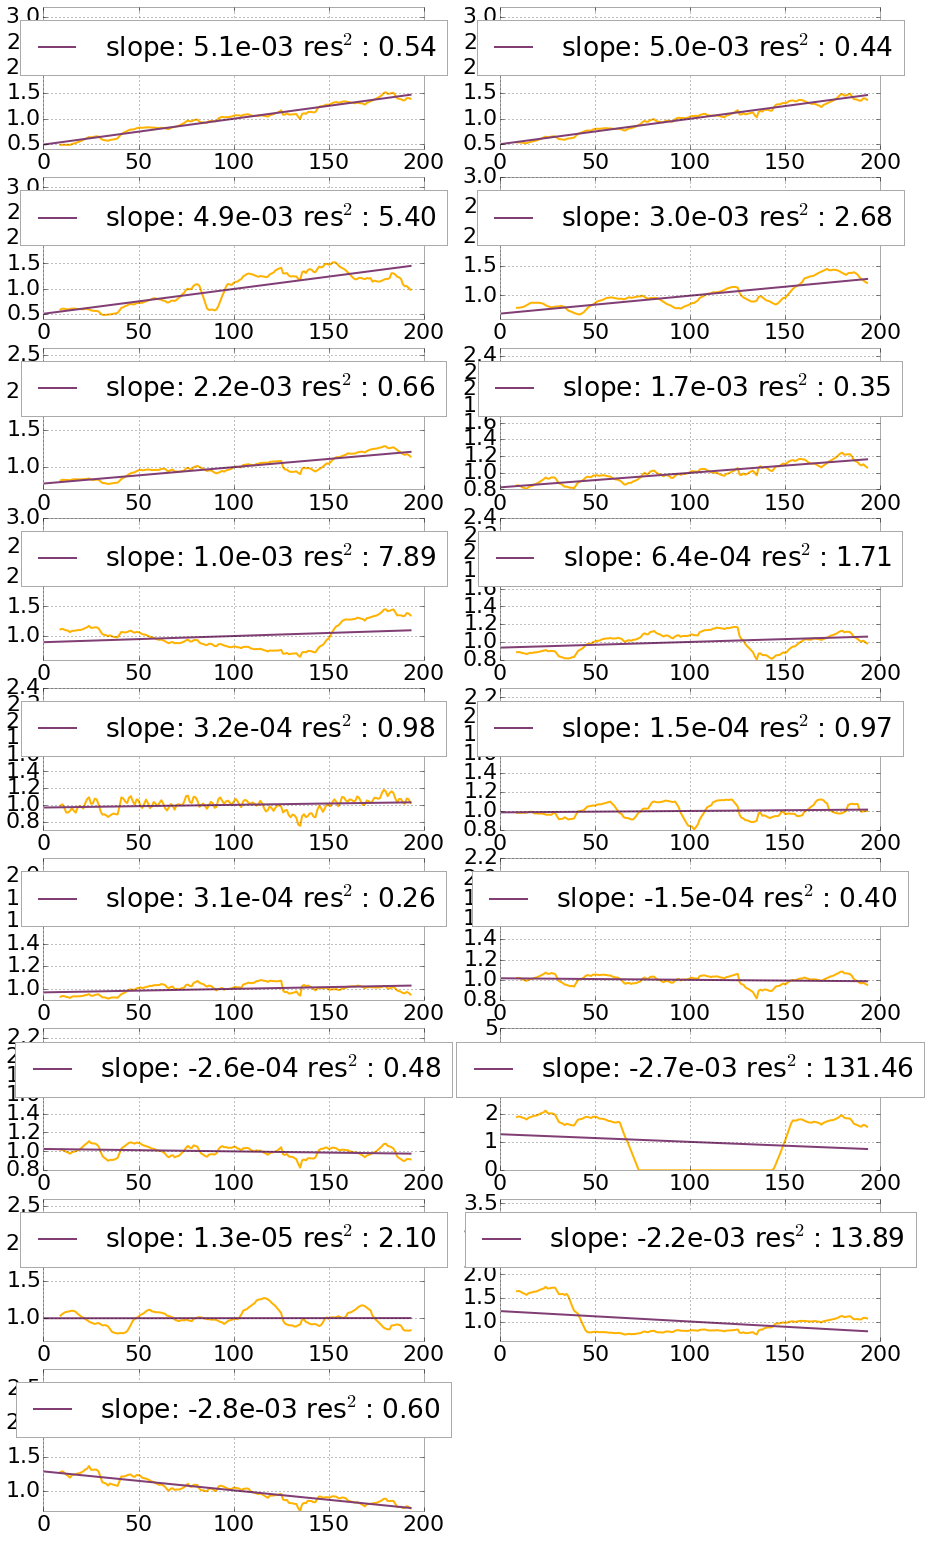

In [31]:
slopes = np.zeros((len(countratio),2), float)

#I am making this plot just to illustrate the method: after removing obviously
#weird time series i can fit a line to the remaining ones. 
#the residuals of the line fit will tell me how "linear" the time series trend is,
#i.e. if it has a lot of structure the sum of the residual sq will be high
#the slope will tell me how steep the trend is
sindex = sorted(countratio[countratio < 10])[-1]
fig = pl.figure(figsize = (15,30))
j = 0
for sindex in np.argsort(countratio):    
    if not sindex in [7, 8, 9, 12, 17, 22]:
        j=j+1
        ax = fig.add_subplot(10,2,j)
        smoothnormed = smoothrides[sindex]/np.nanmean(smoothrides[sindex])
        ax.plot(smoothnormed)

        fitpars = (np.polyfit(np.arange(N)[~np.isnan(smoothnormed)], 
                          smoothnormed[~np.isnan(smoothnormed)], 1))
        slopes[sindex][0] = fitpars[0]
        slopes[sindex][1] = np.nansum((smoothnormed - \
                           np.poly1d(fitpars)(np.arange(N)))**2)
        ax.plot(np.arange(N), np.poly1d(fitpars)(np.arange(N)), 
                label  = r"slope: {0:.1e} res$^2$: {1:.2f}".format(slopes[sindex][0], 
                                                                   slopes[sindex][1]))
        ax.set_ylim(ax.get_ylim()[0],ax.get_ylim()[1]*2)
        ax.legend(loc="upper center")



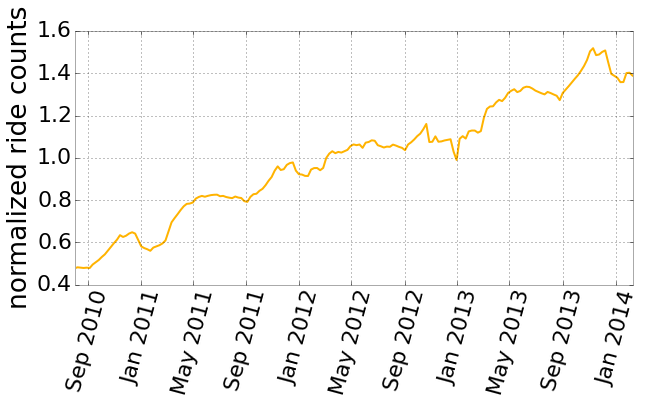

In [32]:
#removing bad line fits by maksing (with NaN) those that give sum(res^2)>1
#(note the comma  before the equal in the second line of code below 
#allows me to pull only the first element returned by np.where: 
#which is the array of locations where the condition is verified

slopes[:,0][slopes[:,1] > 1] = float(NaN)
maxslope, = np.where(slopes[:,0] == max(slopes[:,0]))
                                                                    
fig = pl.figure(figsize=(10, 10))
ax = fig.add_subplot(211)
ax.plot(rng, smoothrides[maxslope[0]]/np.nanmean(smoothrides[maxslope[0]]))
pl.xticks(rotation = 75)
ax.set_ylabel("normalized ride counts")

##Caption: 
###ridership type that shows the steepest, continuous upward trend:


In [33]:
print ("index {0:d} slope {1:.2e}".format(maxslope[0],
                                        slopes[maxslope[0]][0]))
print ("ride type: "+ridetype[maxslope[0]])

index 16 slope 5.10e-03
ride type: sen


##senior passes have a steady increased in usage over the period considered

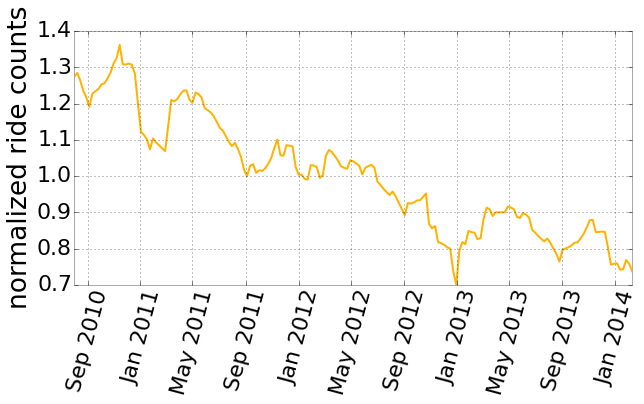

In [34]:
minslope, = np.where(slopes[:,0] == min(slopes[:,0]))
fig = pl.figure(figsize=(10, 10))
ax = fig.add_subplot(211)
ax.plot(rng, smoothrides[minslope[0]]/np.nanmean(smoothrides[minslope[0]]))
pl.xticks(rotation = 75)

ax.set_ylabel("normalized ride counts")

##Caption:
###the ridership type that shows the steepest downward continuous trend:
    

In [35]:
print ("steapest downward trend:  index {0:d} slope {1:.2e}".format(minslope[0], 
                                                                    slopes[minslope[0]][0]))
print ("ride type: "+ridetype[minslope[0]])

steapest downward trend:  index 13 slope -2.81e-03
ride type: month


##monthly passes have steadily decreased in usage

#Task 3: finding periods

## to find periods on a station by station basis we work with 600 time series, summing over the ridership type, and we look for peaks in the power spectrum: the absolute value (or the square) the Fourier transform 

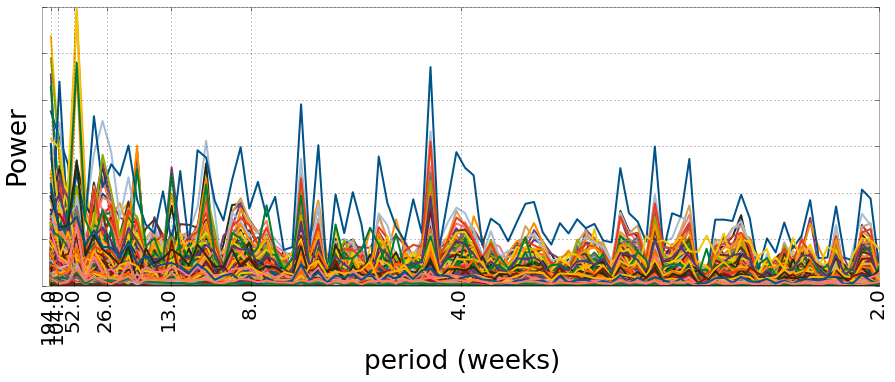

In [36]:
ridesbystation = np.nansum(mta, axis=1)
fig = pl.figure(figsize = (15,5))
ax = fig.add_subplot(111)
#notice that I am using the absolute value of the fourier transform for the real frequencies 
#(real = positive). I chose only the real frequencies by using the np.erfft function (instead of np.fft)
#I get the real part of the Fourier transform by using the absolute value of the fourier transform
#I could also use the square of the fourier transforms of the real frequencies (positive)
#both get rid of the complex part of the fourier transform  leaving me with the real part
#and since I am only interested in relative values (which frequency has the highest peak, 
#which time series has the highet peak at that frequency etc) I can use either abs or ^2
this_ffts =  [np.abs(np.fft.rfft(rbs)) for rbs in ridesbystation]

for this_fft in this_ffts:
    ax.plot(np.fft.rfftfreq(N, 1.0)[1:],(this_fft[1:]))
#the  frequencies I want myplot to show on the x axis
allperiods = [1.0/194, 1./104, 1.0/52, 1.0/26, 1.0/13, 1.0/8, 1.0/4, 1.0/2]
ax.set_xticks (allperiods)
#I want to x-axis labels in period, not frequency, cause they are easier to read. 
#period = 1/frequency
ax.set_xticklabels([ "%s"%(1/f) for f in allperiods], rotation=90, fontsize=20)
ax.set_yticklabels([''*len(ax.get_yticklabels())])
pl.xlabel("period (weeks)")
pl.ylabel("Power")


##Caption: 
###Power (absolute value of the Fourier transform) of the ridership of 600 subway stations. The peaks indicate periodicity: there are visible peaks on periods of 4 weeks (monthly period) and 52 weeks (annual period)

In [37]:
print ("periods where the Power is calculated: \n", 1.0/np.fft.rfftfreq(N, 1.0)[1:])

periods where the Power is calculated: 
 [ 194.           97.           64.66666667   48.5          38.8
   32.33333333   27.71428571   24.25         21.55555556   19.4
   17.63636364   16.16666667   14.92307692   13.85714286   12.93333333
   12.125        11.41176471   10.77777778   10.21052632    9.7
    9.23809524    8.81818182    8.43478261    8.08333333    7.76
    7.46153846    7.18518519    6.92857143    6.68965517    6.46666667
    6.25806452    6.0625        5.87878788    5.70588235    5.54285714
    5.38888889    5.24324324    5.10526316    4.97435897    4.85
    4.73170732    4.61904762    4.51162791    4.40909091    4.31111111
    4.2173913     4.12765957    4.04166667    3.95918367    3.88
    3.80392157    3.73076923    3.66037736    3.59259259    3.52727273
    3.46428571    3.40350877    3.34482759    3.28813559    3.23333333
    3.18032787    3.12903226    3.07936508    3.03125       2.98461538
    2.93939394    2.89552239    2.85294118    2.8115942     2.77142857
    

In [38]:
#among the frequencies calculated  the closest one to an annual frequency, or
#52 weeks is 48.5 weeks is the 4th cell of the fourier transform array. 
#To see why 48.5 look at the manual of the np.fft.rfftfreq() function!
#I am sorting the time series by increasing power in cell 4 
#and taking the indeces of the sorted array 
#(the sorted indecesis what argsort() returns)

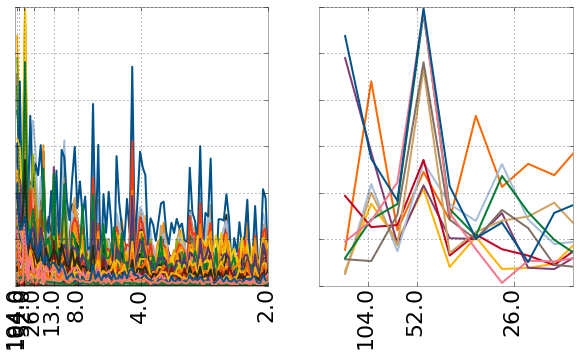

In [39]:
fig = pl.figure(figsize=(10,5))
ax = fig.add_subplot(121)
for this_fft in np.array(this_ffts):
    ax.plot(np.fft.rfftfreq(N, 1.0)[1:],(this_fft[1:]))
ax.set_xlim(0,0.05)
ax.set_xticks (allperiods)
ax.set_xticklabels([ "%s"%(1/f) for f in allperiods], rotation=90)
ax.set_yticklabels([''*len(ax.get_yticklabels())])

ax = fig.add_subplot(122)
yearly_sorted =  np.array(this_ffts).T[4].argsort()
#and removing nan values
#yearly_sorted = yearly_sorted[~np.isnan(np.array(this_ffts)[yearly_sorted[:],4])]

for this_fft in np.array(this_ffts)[yearly_sorted[-10:]]:
    ax.plot(np.fft.rfftfreq(N, 1.0)[1:],(this_fft[1:]))
allperiods = [1./104, 1.0/52, 1.0/26]
ax.set_xlim(0,0.05)
ax.set_xticks (allperiods)
ax.set_xticklabels([ "%s"%(1/f) for f in allperiods], rotation=90)
ax.set_yticklabels([''*len(ax.get_yticklabels())])

##Caption: 
###Zoom-in of the Power spectrum of the ridership of 600 subway stations around the annual peak (left) and of the ones that display the most prominent ~1-year periodicity (right)

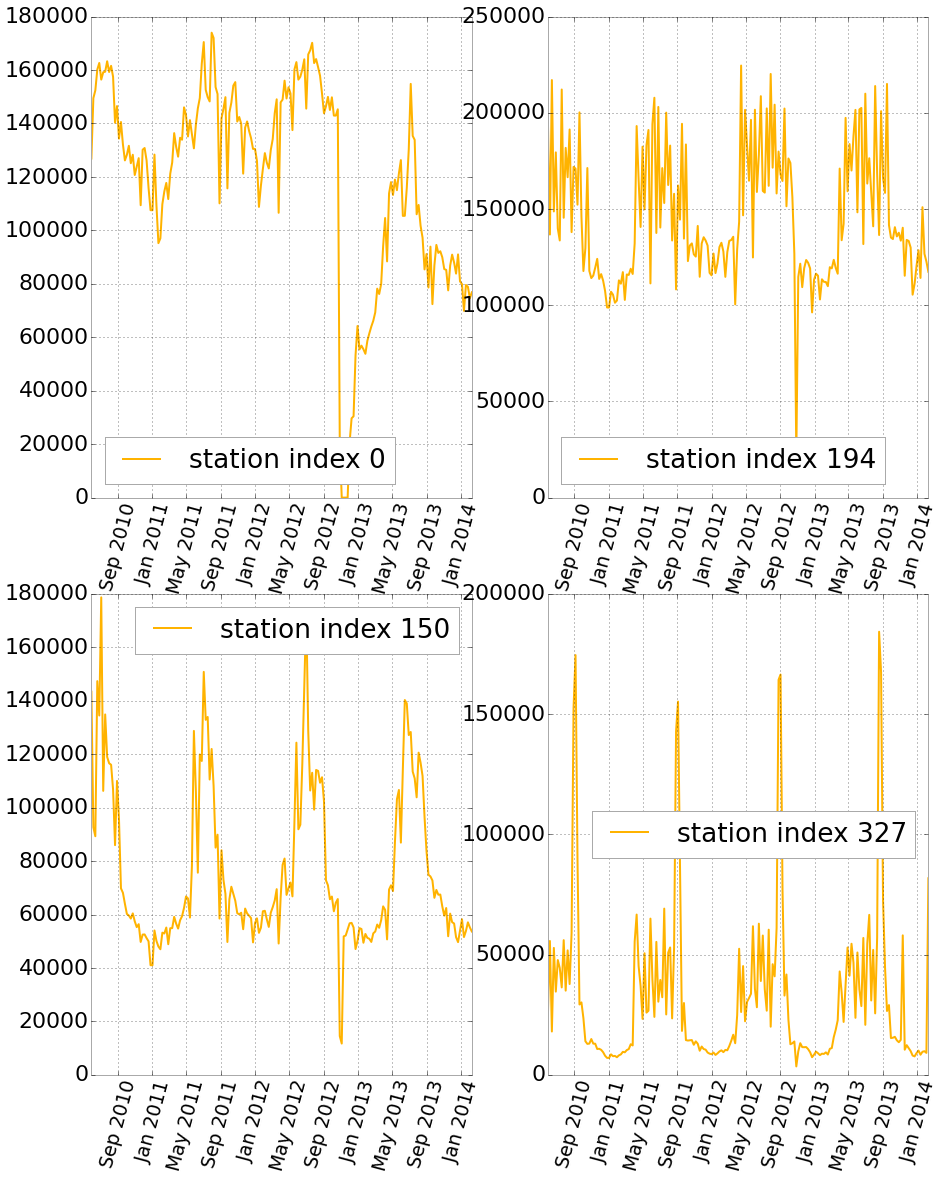

In [40]:
fig = pl.figure(figsize=(15,50))
for i,j in enumerate(yearly_sorted[-1:-5:-1]):
    
    ax = fig.add_subplot(5,2,i+1)
    ax.plot(rng, ridesbystation[j], label="station index %d"%j)
    pl.legend(loc = 'best')
    pl.xticks(rotation = 75, fontsize = 19)

#Caption
#The 4 stations that show the most prominant annual trends.
#Notice the peak in ridership around September for station 327. I think that is the US Open!
#If we could trivially retrieve the stations that are associated to each index in the data cube we could figure out  what each station peak corresponds to given the location of the station. otherwise they are just fun guesses

###(notice that you may have a slightly different result if you cleaned your data differently)

Extra Credit: clustering the time series

In [41]:
from sklearn.cluster import KMeans


#clustering in 10 clusters

data = np.load("MTA_Fare.npy")

tots = data.transpose(2,0,1).reshape(data.shape[2], data.shape[1]*data.shape[0]).T

#I have to remove the time series that have NaN's because sklearn.cluster K-means 
#does not deal well with NaN's (or at all in fact)
#the next line does the trick: the std is NaN if there are NaN's in the time series
tots = tots[tots.std(1)>0]

#I need to select the number of clusters. I arbitrarily choose 10
km = KMeans(n_clusters=10)

##important! to perform K-means I have to "whiten" the data!
#we will talk about it more in class
vals = ((tots.T - tots.mean(1))/tots.std(1)).T

km.fit(vals)

KMeans(copy_x=True, init='k-means++', max_iter=300, n_clusters=10, n_init=10,
    n_jobs=1, precompute_distances=True, random_state=None, tol=0.0001,
    verbose=0)

In [42]:
#this tells me which cluster each time series belongs to
km.labels_


array([4, 4, 4, ..., 8, 3, 8], dtype=int32)

In [43]:
#this woulc tell me the distance to the cluster center of each time series
distance = (np.array([vals - km.cluster_centers_[i] for i in range (len(km.cluster_centers_))])**2)

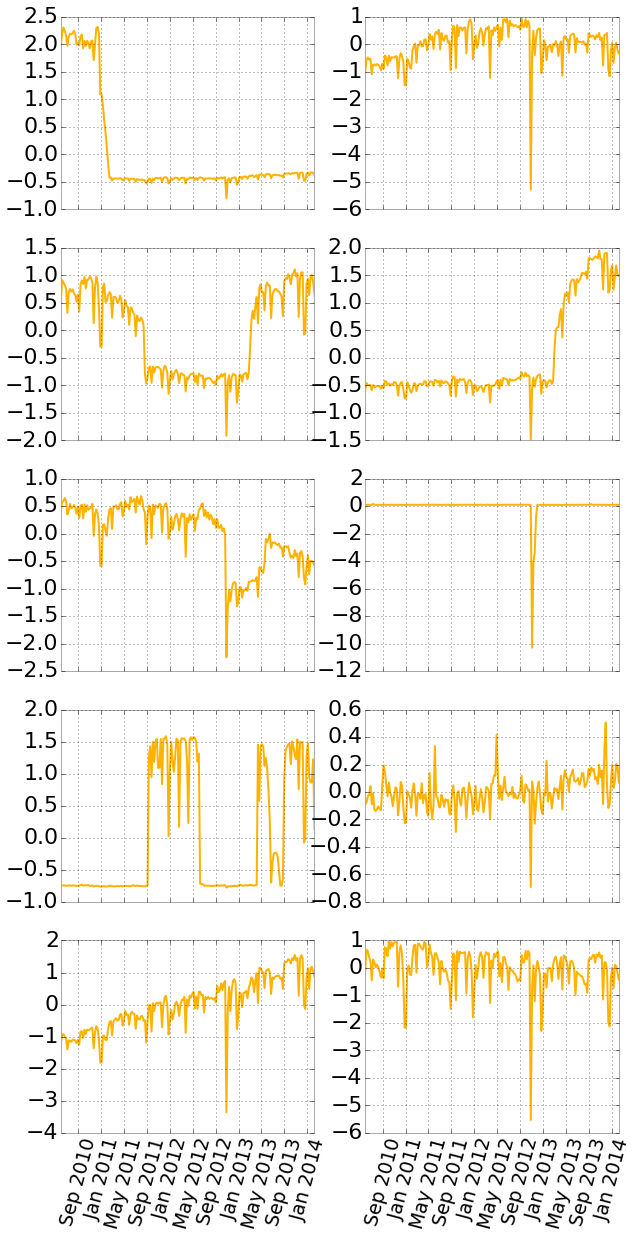

In [44]:
fig = pl.figure(figsize = (10,20))
for i,Xc in enumerate(km.cluster_centers_):
    ax = fig.add_subplot(5,2,(i+1))
    ax.plot(rng, Xc)

    if i > 7:
        pl.xticks(rotation = 75, fontsize = 19)
    else:
        ax.set_xticklabels([''*len(ax.get_xticklabels())])


#Caption 
##Kmean cluster centers, chosing 10 as the number of clusters. 
####I see a cluster with an annual period, 
####a steadily decreasing and a steadily increasing trend are visible as cluster centers. Other structure is visible. 
####cards discontinued in  cluster 3? 
####cards that became a lot more popular in cluster 7?  
###these feature remain misterious and further analysis wich considers metadata (additional information such as the location of the station) should be included to interpret the clusters and the trends

